# Snake RL — Training Run Analysis

Plots metric curves for DQN training runs logged to MLflow.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path('..') / 'src'))

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from IPython.display import Image

sns.set_theme(style='darkgrid', palette='tab10')
plt.rcParams['figure.dpi'] = 120

try:
    import mlflow
    from mlflow.tracking import MlflowClient
    DB_PATH = (Path('..') / 'mlruns' / 'mlflow.db').resolve()
    TRACKING_URI = f'sqlite:///{DB_PATH}'
    mlflow.set_tracking_uri(TRACKING_URI)
    client = MlflowClient(TRACKING_URI)
    exp = client.get_experiment_by_name('snake-rl')
    if exp is None:
        raise ValueError("Experiment 'snake-rl' not found in MLflow DB")
    print(f'Tracking URI: {TRACKING_URI}')
    print(f'Experiment ID: {exp.experiment_id}')
except Exception as e:
    print(f'MLflow unavailable: {e}')
    print('Static PNGs will be displayed instead of live charts.')
    client = None
    exp = None

Tracking URI: sqlite:////home/jgalloway/workspace/snake_rl/mlruns/mlflow.db
Experiment ID: 1


## Load MLflow runs

In [2]:
def get_metric_df(run_id: str, metric: str) -> pd.DataFrame:
    """Return a DataFrame with columns [step, value] for a given metric."""
    if client is None:
        return pd.DataFrame(columns=['step', metric])
    history = client.get_metric_history(run_id, metric)
    if not history:
        return pd.DataFrame(columns=['step', metric])
    return pd.DataFrame({'step': [h.step for h in history], metric: [h.value for h in history]})


if client is not None:
    def get_run_summary(run) -> dict:
        import datetime
        p = run.data.params
        m = run.data.metrics
        return {
            'run_id': run.info.run_id[:8],
            'start': datetime.datetime.fromtimestamp(run.info.start_time / 1000).strftime('%Y-%m-%d %H:%M'),
            'status': run.info.status,
            'food': float(p.get('reward.food', 'nan')),
            'collision': float(p.get('reward.collision', 'nan')),
            'toward': float(p.get('reward.toward', 'nan')),
            'ent_coef': float(p.get('ppo.ent_coef', 'nan')),
            'lr': float(p.get('ppo.learning_rate', 'nan')),
            'grid': f"{p.get('env.grid_w')}×{p.get('env.grid_h')}",
            'max_steps': int(p.get('env.max_steps', 0)),
            'final_ep_rew': m.get('ep_rew_mean', float('nan')),
            'final_ep_len': m.get('ep_len_mean', float('nan')),
            'final_entropy': m.get('entropy', float('nan')),
            'final_value_loss': m.get('value_loss', float('nan')),
        }
    all_runs = client.search_runs(exp.experiment_id, order_by=['start_time ASC'])
    summaries = [get_run_summary(r) for r in all_runs]
    summary_df = pd.DataFrame(summaries)
    print(f'{len(all_runs)} run(s) found in MLflow')
    display(summary_df)
else:
    print('MLflow data not available — see saved PNGs below.')
    all_runs = []

5 run(s) found in MLflow


,run_id,start,status,food,collision,toward,ent_coef,lr,grid,max_steps,final_ep_rew,final_ep_len,final_entropy,final_value_loss
0,379c8553,2026-03-24 22:12,FINISHED,16.0,0.0,0.0,NaN,NaN,16×16,300,9.2996,50.96,NaN,NaN
1,4122577e,2026-03-24 22:46,FINISHED,16.0,0.0,0.0,NaN,NaN,16×16,300,13.9987,56.87,NaN,NaN
2,af72241e,2026-03-24 23:19,FINISHED,16.0,0.0,0.0,NaN,NaN,16×16,300,7.7711,58.11,NaN,NaN
3,3e2ef0c5,2026-03-24 23:43,RUNNING,16.0,0.0,0.0,NaN,NaN,16×16,300,187.6748,144.43,NaN,NaN
4,92e643b6,2026-03-25 09:21,FINISHED,16.0,0.0,0.0,NaN,NaN,16×16,300,209.2657,159.43,NaN,NaN


## Plot run curves

In [3]:
def plot_dqn_run_curves(run_id_prefix: str, label: str = None):
    """Plot metric curves for a DQN run by its MLflow run ID prefix."""
    if client is None:
        print('MLflow unavailable — cannot load run curves.')
        return
    all_r = client.search_runs(exp.experiment_id)
    matches = [r for r in all_r if r.info.run_id.startswith(run_id_prefix)]
    if not matches:
        print(f'No run found with prefix {run_id_prefix!r}')
        return
    run = matches[0]
    label = label or run.info.run_id[:8]

    fig, axes = plt.subplots(1, 4, figsize=(18, 4))
    fig.suptitle(f'DQN Run: {label}', fontsize=12)

    metrics = [
        ('ep_rew_mean',       'Mean Episode Reward'),
        ('ep_len_mean',       'Mean Episode Length'),
        ('loss',              'TD Loss'),
        ('exploration_rate',  'Epsilon (exploration rate)'),
    ]

    for ax, (metric, ylabel) in zip(axes, metrics):
        df = get_metric_df(run.info.run_id, metric)
        if df.empty:
            ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
            ax.set_title(ylabel)
            continue
        ax.plot(df['step'], df[metric], alpha=0.4, linewidth=0.8)
        if len(df) > 20:
            smoothed = df[metric].rolling(window=max(1, len(df)//20), center=True).mean()
            ax.plot(df['step'], smoothed, linewidth=2)
        ax.set_xlabel('Steps')
        ax.set_ylabel(ylabel)
        ax.set_title(ylabel)
        ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
        if metric == 'ep_rew_mean':
            food = float(run.data.params.get('reward.food', 16))
            ax.axhline(food, color='green', linestyle='--', alpha=0.5, label=f'1 food ({food})')
            ax.legend(fontsize=8)

    plt.tight_layout()
    plt.show()


# Example (fill in run ID prefix after starting training):
# plot_dqn_run_curves('abc12345', label='Run 5 — DQN baseline')

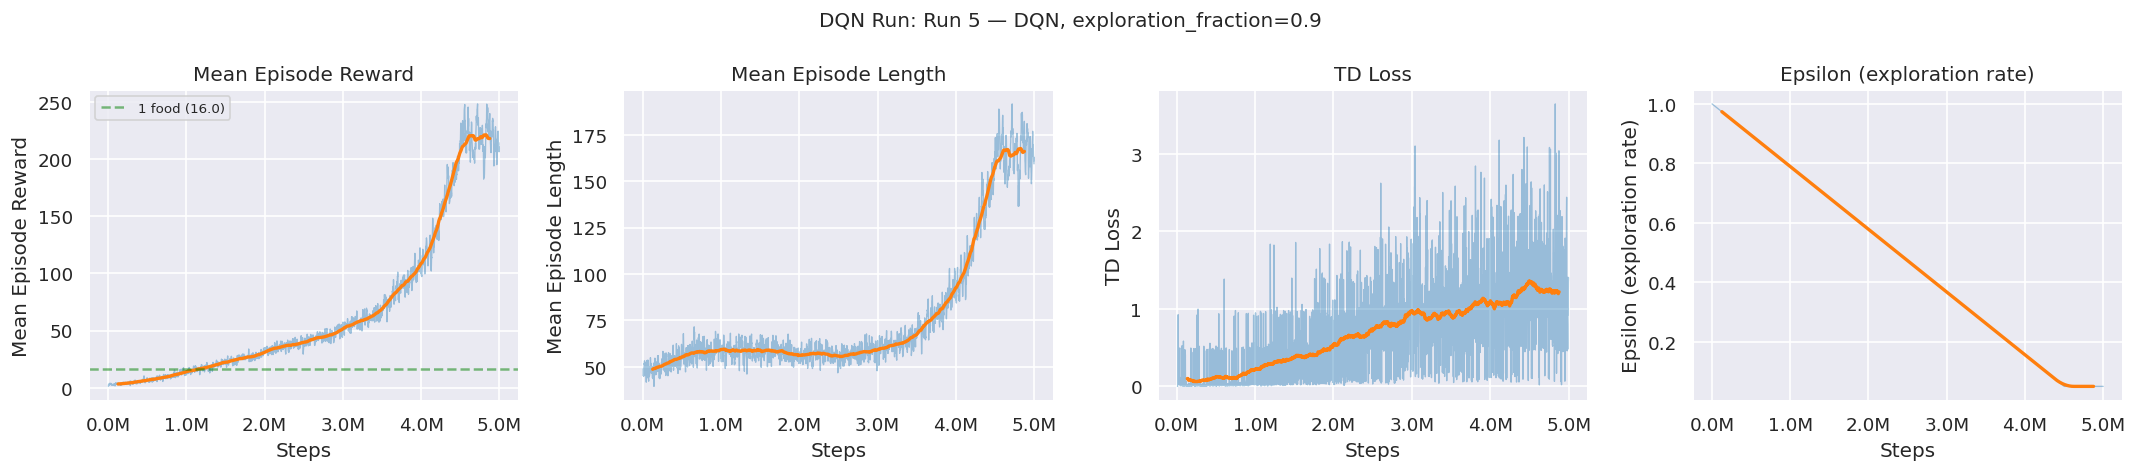

In [4]:
# Plot the final DQN run
plot_dqn_run_curves('92e643b6', label='Run 5 — DQN, exploration_fraction=0.9')